In [1]:
from astroquery.ipac.irsa import sha
from astroquery.ipac.irsa import Irsa
from astropy import units as u
from astropy.coordinates import SkyCoord

In [2]:
sgrb2tb = Irsa.query_region(SkyCoord(0.69*u.deg, 0*u.deg, frame='galactic'),
                  radius=30*u.arcmin,
                  catalog='irs_enhv211',
                 )
crds = SkyCoord(sgrb2tb['ra'], sgrb2tb['dec'], frame='icrs')

In [3]:
import pylab as pl

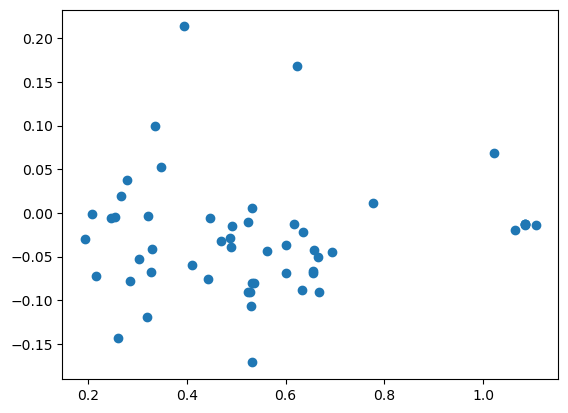

In [4]:
pl.scatter(crds.galactic.l, crds.galactic.b)

In [5]:
from astropy.io import fits
from astropy.wcs import WCS

In [6]:
fh = fits.open('/orange/adamginsburg/sgrb2/2013.1.00269.S/continuum/SgrB2_selfcal_full_TCTE_selfcal5_ampphase.image.pbcor.fits')
ww = WCS(fh[0].header)

indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


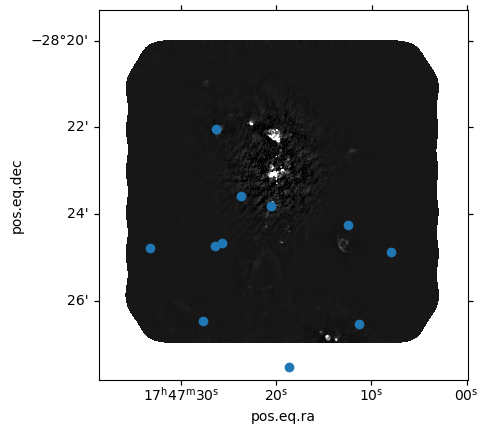

In [7]:
ax = pl.subplot(projection=ww)
ax.imshow(fh[0].data, cmap='gray', vmax=0.01, vmin=-0.001)
lims = ax.axis()
ax.scatter_coord(crds)
ax.axis(lims);

In [11]:
sgrb2tb['heritagefilename'][0]

'/sha/archive/proc/IRSX010300/r23964416/enhanced/SPITZER_S5_23964416_06_merge.tbl'

In [19]:
import requests
requests.get(f'https://irsa.ipac.caltech.edu/applications/Spitzer/{sgrb2tb['heritagefilename'][0]}')

<Response [404]>

In [21]:
sgrb2tb_ssa = Irsa.query_ssa(pos=SkyCoord(0.69*u.deg, 0*u.deg, frame='galactic'),
                  diameter=30*u.arcmin,
                  #catalog='irs_enhv211',
                 )
sgrb2tb_ssa = sgrb2tb_ssa.to_table()

<DALResultsTable length=205858>
       s_ra              s_dec        ... dataset_length upload_row_id
       deg                deg         ...                             
     float64            float64       ...     int32          int64    
----------------- ------------------- ... -------------- -------------
       266.700885          -28.479039 ...             --             1
       266.700885          -28.479039 ...             --             1
       266.700885          -28.479039 ...             --             1
        266.88685          -28.441475 ...             --             1
        266.88685          -28.441475 ...             --             1
        266.88685          -28.441475 ...             --             1
        266.88685          -28.441475 ...             --             1
        266.88685          -28.441475 ...             --             1
        266.88685          -28.441475 ...             --             1
              ...                 ... ...    

In [29]:
sgrb2tb_ssa['calib_level', 'facility_name', 'access_url'][sgrb2tb_ssa['calib_level'] >= 3]

calib_level,facility_name,access_url
int16,object,object
3,SOFIA,https://irsa.ipac.caltech.edu/data/SOFIA/FIFI-LS/L4/p3987/data/g7/F0312_FI_IFS_0400321_RED_WXY_100015-200141.fits
3,SOFIA,https://irsa.ipac.caltech.edu/data/SOFIA/FIFI-LS/L4/p3987/data/g7/F0312_FI_IFS_0400321_RED_WXY_100015-200141.png
3,Spitzer Space Telescope,https://irsa.ipac.caltech.edu/data/SPITZER/Enhanced/IRS/spectra/IRSX010300/r23974656/enhanced/SPITZER_S5_23974656_04_merge.tbl
3,SOFIA,https://irsa.ipac.caltech.edu/data/SOFIA/FIFI-LS/L4/p3992/data/g8/F0315_FI_IFS_0400322_RED_WXY_300247-400006.fits
3,SOFIA,https://irsa.ipac.caltech.edu/data/SOFIA/FIFI-LS/L4/p3992/data/g8/F0315_FI_IFS_0400322_RED_WXY_300247-400006.png
3,SOFIA,https://irsa.ipac.caltech.edu/data/SOFIA/FIFI-LS/L4/p3992/data/g7/F0315_FI_IFS_0400322_BLU_WXY_300247-400006.fits
3,SOFIA,https://irsa.ipac.caltech.edu/data/SOFIA/FIFI-LS/L4/p3992/data/g7/F0315_FI_IFS_0400322_BLU_WXY_300247-400006.png
3,SOFIA,https://irsa.ipac.caltech.edu/data/SOFIA/FIFI-LS/L4/p4028/data/g39/F0312_FI_IFS_0400321_RED_WXY_100005-400006.fits
3,SOFIA,https://irsa.ipac.caltech.edu/data/SOFIA/FIFI-LS/L4/p4028/data/g39/F0312_FI_IFS_0400321_RED_WXY_100005-400006.png


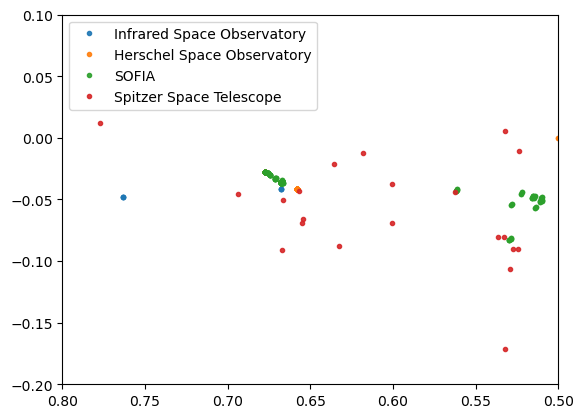

In [38]:
#for facility in set(sgrb2tb_ssa['facility_name']):
for facility in ['Infrared Space Observatory', 'Herschel Space Observatory', 'SOFIA', 'Spitzer Space Telescope']:
    filt = (sgrb2tb_ssa['facility_name'] == facility) & (sgrb2tb_ssa['calib_level'] >= 3)
    crds = SkyCoord(sgrb2tb_ssa['s_ra'][filt], sgrb2tb_ssa['s_dec'][filt], frame='fk5', unit=(u.deg, u.deg))
    pl.plot(crds.galactic.l, crds.galactic.b, '.', alpha=0.9, label=facility)
pl.legend(loc='best');
pl.axis([0.8, 0.5, -0.2, 0.1]);

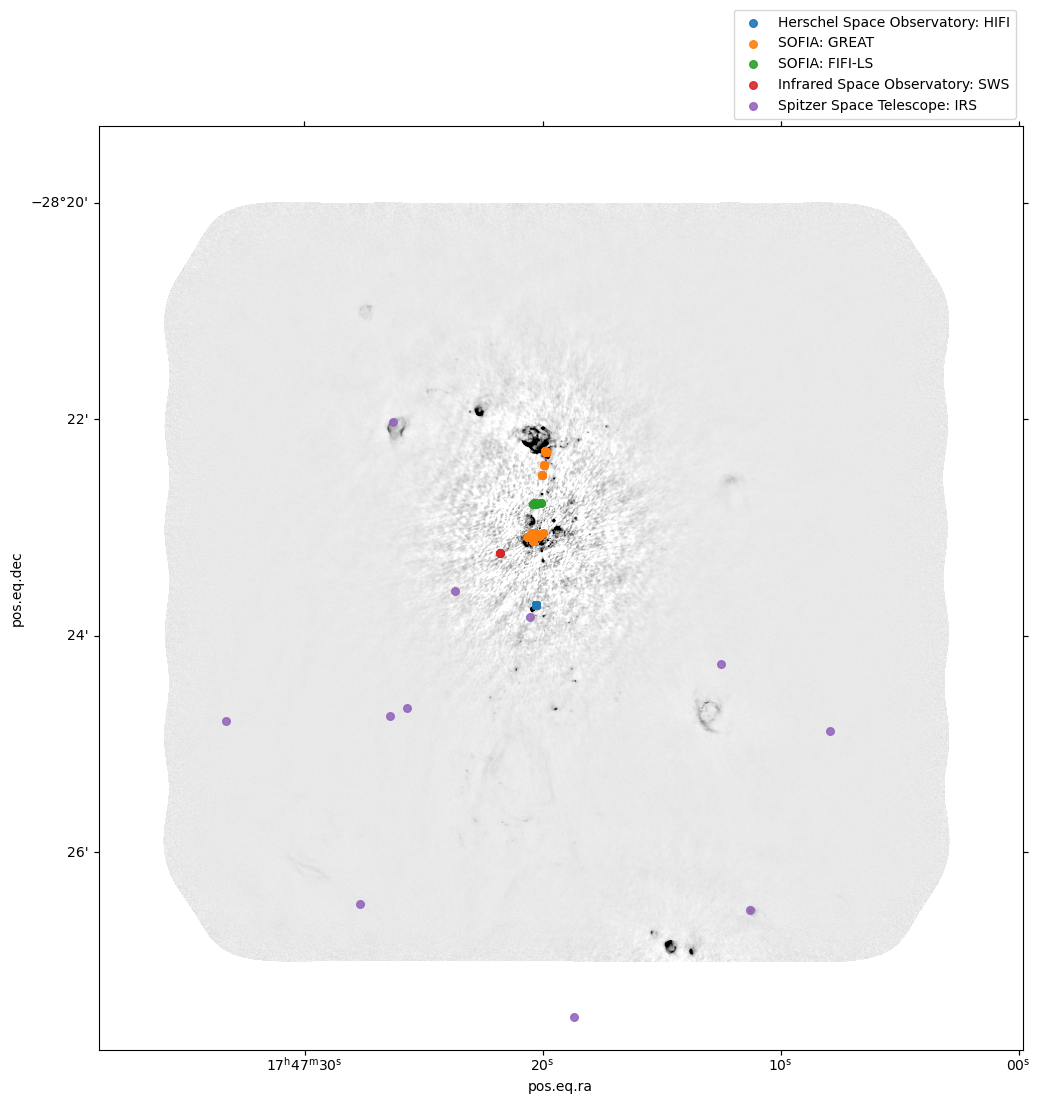

In [50]:
pl.figure(figsize=(12,12))
ax = pl.subplot(projection=ww)
ax.imshow(fh[0].data, cmap='gray_r', vmax=0.01, vmin=-0.001)
lims = ax.axis()
for facility in ['Herschel Space Observatory', 'SOFIA', 'Infrared Space Observatory', 'Spitzer Space Telescope']:
    filt = (sgrb2tb_ssa['facility_name'] == facility) & (sgrb2tb_ssa['calib_level'] >= 3)
    for instrument in set(sgrb2tb_ssa['dataid_instrument'][filt]):
        filt2 = filt &(sgrb2tb_ssa['dataid_instrument'] == instrument)
        crds = SkyCoord(sgrb2tb_ssa['s_ra'][filt2], sgrb2tb_ssa['s_dec'][filt2], frame='fk5', unit=(u.deg, u.deg))
        ax.scatter_coord(crds, s=30, alpha=0.9, label=f'{facility}: {instrument}',)
pl.legend(loc='lower right', bbox_to_anchor=[1, 1, 0, 0]);
ax.axis(lims);

In [24]:
sgrb2tb_ssa.colnames

['s_ra',
 's_dec',
 'facility_name',
 'dataid_instrument',
 'dataproduct_subtype',
 'calib_level',
 'dataset_type',
 'dataid_bandpass',
 'curation_publisherdid',
 'min_wavelength',
 'max_wavelength',
 'spec_rp',
 'spec_val',
 'spec_bw',
 'energy_transition_species',
 'energy_transition_transition',
 'energy_restwav',
 'dataid_title',
 'access_url',
 'access_format',
 'access_size',
 'texposure',
 'dataid_collection',
 'dataid_date',
 'proposal_id',
 'dataset_datamodel',
 'curation_reference',
 'target_name',
 's_fov',
 'tstart',
 'tstop',
 'tmid',
 'texposure_eff',
 'coord_obs',
 'curation_publisher',
 'curation_date',
 'dataid_creator',
 'dataset_length',
 'upload_row_id']

In [66]:
import pyspeckit
import requests
from io import BytesIO, StringIO
from astropy.table import Table
from astropy.io import ascii

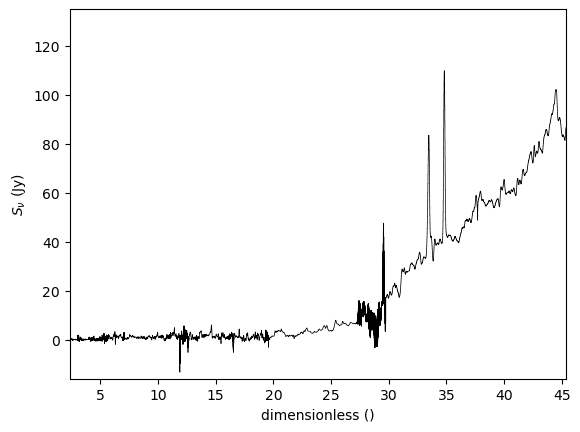

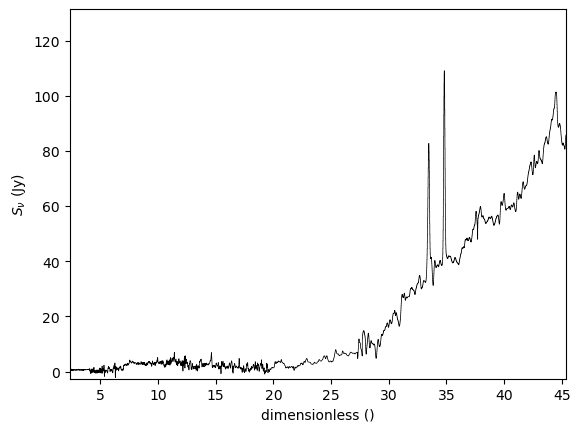

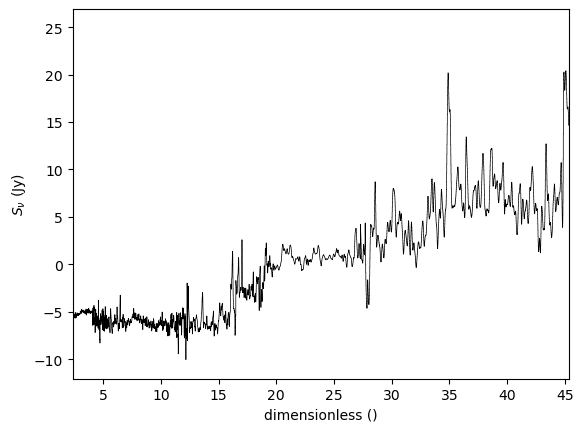

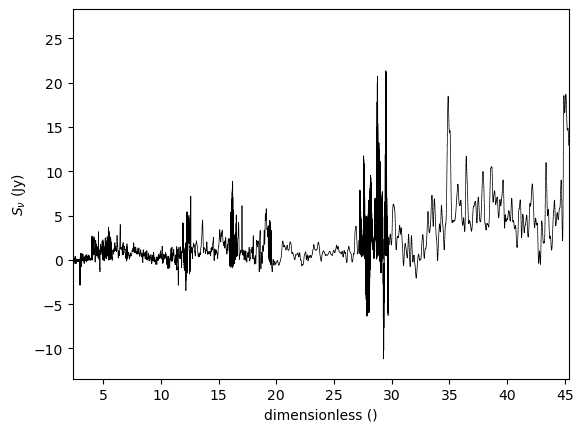

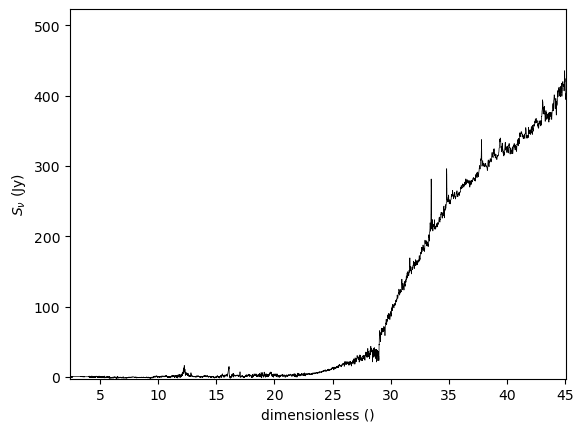

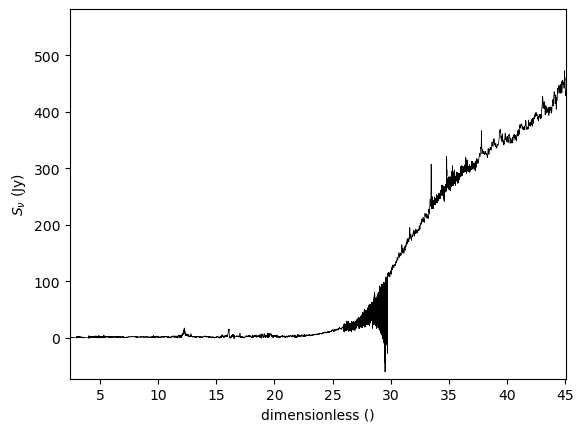

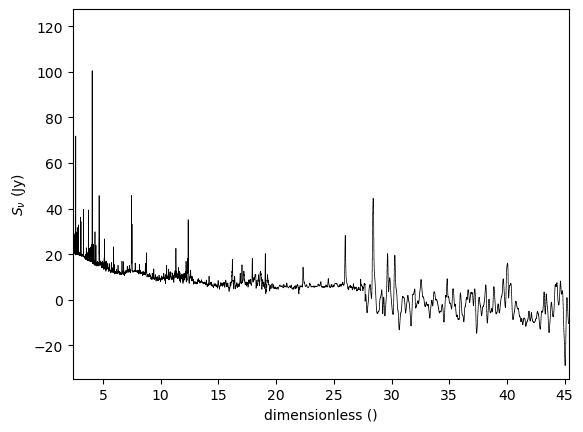

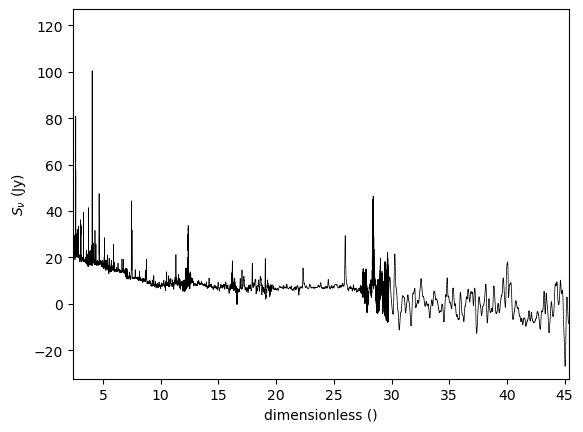

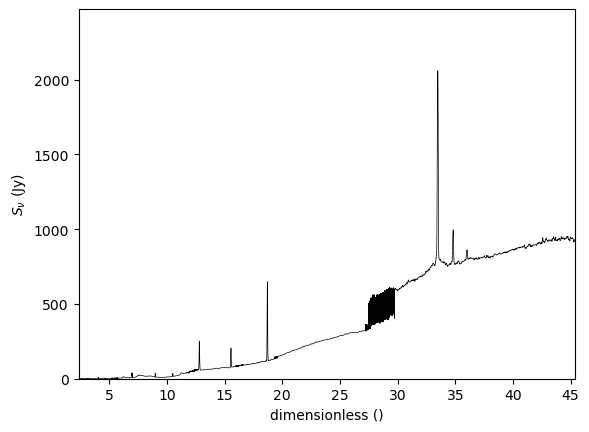

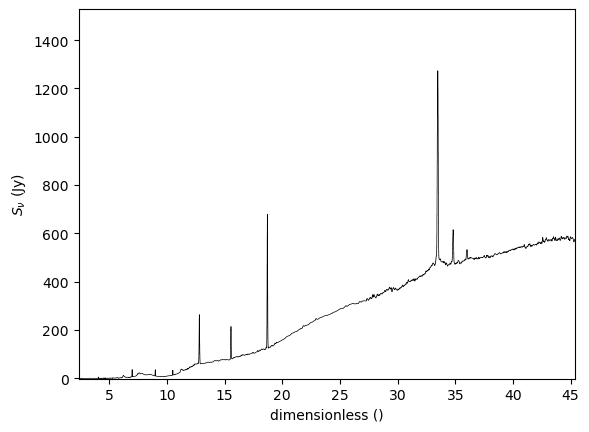

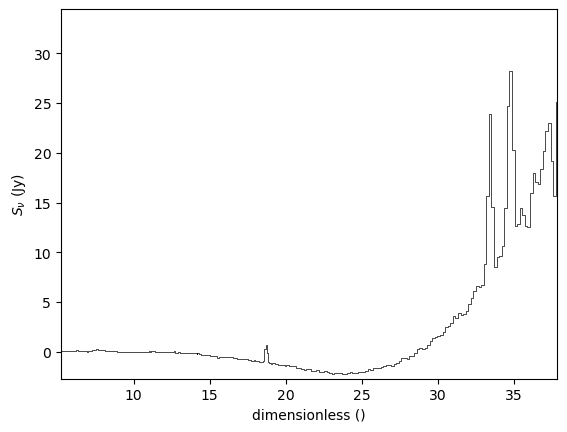

In [72]:
count = 0
for facility in ['Infrared Space Observatory', 'Spitzer Space Telescope']:
    filt = (sgrb2tb_ssa['facility_name'] == facility) & (sgrb2tb_ssa['calib_level'] >= 3)
    urls = sgrb2tb_ssa[filt]['access_url']
    for url in urls:
        if url.endswith('tbl'):
            resp = requests.get(url)
            tb = Table.read(BytesIO(resp.content), format='ascii.ipac')
            if 'wavelength' in tb.colnames:
                sp = pyspeckit.Spectrum(xarr=tb['wavelength'], data=tb['flux_density'])
            elif 'lambda' in tb.colnames:
                sp = pyspeckit.Spectrum(xarr=tb['lambda'], data=tb['Flux'])
            else:
                print(tb.colnames)
                raise
            sp.plotter()
            count += 1
        if count > 10:
            break
    if count > 10:
        break

In [57]:
url

'https://irsa.ipac.caltech.edu/data/SPITZER/Enhanced/IRS/spectra/IRSX007500/r18381568/enhanced/SPITZER_S5_18381568_02_merge.tbl'